In [ ]:
import pandas as pd

# ─────────────────────────────────────────────
# STEP 1 — Load SP500 2.csv and keep only Date & Close
# ─────────────────────────────────────────────
sp500_2 = pd.read_csv("SP500 2.csv")
sp500_2 = sp500_2[["Date", "Close"]].copy()

# Rename columns to match the final target names
sp500_2 = sp500_2.rename(columns={"Date": "DATE", "Close": "SP500"})

# Parse dates and resample to monthly (first trading day of each month)
sp500_2["DATE"] = pd.to_datetime(sp500_2["DATE"])
sp500_2 = sp500_2.set_index("DATE").resample("MS").first().reset_index()

print("SP500 2 (cleaned):")
print(sp500_2.head())
print(f"Date range: {sp500_2['DATE'].min().date()} → {sp500_2['DATE'].max().date()}")

# ─────────────────────────────────────────────
# STEP 2 — Load SP500.csv and standardise column names
# ─────────────────────────────────────────────
sp500 = pd.read_csv("SP500.csv")
sp500 = sp500.rename(columns={"observation_date": "DATE"})

# Parse dates and resample to monthly
sp500["DATE"] = pd.to_datetime(sp500["DATE"])
sp500 = sp500.set_index("DATE").resample("MS").first().reset_index()

print("\nSP500 (cleaned):")
print(sp500.head())
print(f"Date range: {sp500['DATE'].min().date()} → {sp500['DATE'].max().date()}")

# ─────────────────────────────────────────────
# STEP 3 — Merge both datasets
# SP500.csv is the primary source; SP500 2.csv fills in the gaps
# ─────────────────────────────────────────────
merged = pd.merge(sp500, sp500_2, on="DATE", how="outer")

# SP500.csv values take priority; SP500 2.csv fills any missing months
merged["SP500"] = merged["SP500_x"].combine_first(merged["SP500_y"])

# Keep only the two final columns
merged = merged[["DATE", "SP500"]].sort_values("DATE").reset_index(drop=True)

# Drop any rows where SP500 is still missing
merged = merged.dropna(subset=["SP500"])

print("\nFinal merged dataset:")
print(merged.head())
print(f"Shape: {merged.shape}")
print(f"Date range: {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")

# ─────────────────────────────────────────────
# STEP 4 — Save to CSV
# ─────────────────────────────────────────────
merged.to_csv("Final_SP500_Monthly_Complete.csv", index=False)
print("\n✅ Saved: Final_SP500_Monthly_Complete.csv")

SP500 2 (cleaned):
        DATE      SP500
0 1927-12-01  17.660000
1 1928-01-01  17.760000
2 1928-02-01  17.530001
3 1928-03-01  17.299999
4 1928-04-01  18.910000
Date range: 1927-12-01 → 2025-08-01

SP500 (cleaned):
        DATE    SP500
0 2021-05-01  4197.05
1 2021-06-01  4202.04
2 2021-07-01  4319.94
3 2021-08-01  4387.16
4 2021-09-01  4524.09
Date range: 2021-05-01 → 2026-05-01

Final merged dataset:
        DATE      SP500
0 1927-12-01  17.660000
1 1928-01-01  17.760000
2 1928-02-01  17.530001
3 1928-03-01  17.299999
4 1928-04-01  18.910000
Shape: (1182, 2)
Date range: 1927-12-01 → 2026-05-01

✅ Saved: Final_SP500_Monthly_Complete.csv


In [ ]:
import pandas as pd
import os

files = [
    "CPIAUCSL.csv",
    "Final_SP500_Monthly_Complete.csv",
    "MCOILWTICO.csv",
    "MSPNHSUS.csv",
    "SP500 2.csv",
    "SP500.csv",
    "T10Y3M.csv",
    "UMCSENT.csv",
    "UNRATE.csv",
    "USREC.csv"
]

for file in files:
    df = pd.read_csv(file)
    if "observation_date" in df.columns:
        df = df.rename(columns={"observation_date": "DATE"})
        df.to_csv(file, index=False)
        print(f"✅ Renamed in: {file}")
    else:
        print(f"⏭️  No 'observation_date' column in: {file}")

✅ Renamed in: CPIAUCSL.csv
⏭️  No 'observation_date' column in: Final_SP500_Monthly_Complete.csv
✅ Renamed in: MCOILWTICO.csv
✅ Renamed in: MSPNHSUS.csv
⏭️  No 'observation_date' column in: SP500 2.csv
✅ Renamed in: SP500.csv
✅ Renamed in: T10Y3M.csv
✅ Renamed in: UMCSENT.csv
✅ Renamed in: UNRATE.csv
✅ Renamed in: USREC.csv


In [ ]:
import pandas as pd

renames = {
    "CPIAUCSL.csv":  {"CPIAUCSL": "CPI"},
    "MCOILWTICO.csv": {"MCOILWTICO": "USOIL"},
    "MSPNHSUS.csv":  {"MSPNHSUS": "Median_House_Price"},
}

for file, mapping in renames.items():
    df = pd.read_csv(file)
    df = df.rename(columns=mapping)
    df.to_csv(file, index=False)
    print(f"✅ {file}: {mapping}")

✅ CPIAUCSL.csv: {'CPIAUCSL': 'CPI'}
✅ MCOILWTICO.csv: {'MCOILWTICO': 'USOIL'}
✅ MSPNHSUS.csv: {'MSPNHSUS': 'Median_House_Price'}


In [ ]:
import pandas as pd

files = [
    "CPIAUCSL.csv",
    "Final_SP500_Monthly_Complete.csv",
    "MCOILWTICO.csv",
    "MSPNHSUS.csv",
    "T10Y3M.csv",
    "UMCSENT.csv",
    "UNRATE.csv",
    "USREC.csv"
]

# Load and resample each file to monthly
dfs = []
for file in files:
    df = pd.read_csv(file, parse_dates=["DATE"])
    df = df.set_index("DATE").resample("MS").first().reset_index()
    dfs.append(df)
    print(f"✅ Loaded: {file} — {df.shape[0]} rows, columns: {df.columns.tolist()}")

# Merge all on DATE using inner join
merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="DATE", how="inner")

# Drop any remaining missing values
merged = merged.dropna()
merged = merged.sort_values("DATE").reset_index(drop=True)

print(f"\nFinal merged shape: {merged.shape}")
print(f"Date range: {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")
print(f"Columns: {merged.columns.tolist()}")

# Save
merged.to_csv("Final_merged_data.csv", index=False)
print("\n✅ Saved: Final_merged_data.csv")

✅ Loaded: CPIAUCSL.csv — 952 rows, columns: ['DATE', 'CPI']
✅ Loaded: Final_SP500_Monthly_Complete.csv — 1182 rows, columns: ['DATE', 'SP500']
✅ Loaded: MCOILWTICO.csv — 484 rows, columns: ['DATE', 'USOIL']
✅ Loaded: MSPNHSUS.csv — 759 rows, columns: ['DATE', 'Median_House_Price']
✅ Loaded: T10Y3M.csv — 533 rows, columns: ['DATE', 'T10Y3M']
✅ Loaded: UMCSENT.csv — 882 rows, columns: ['DATE', 'UMCSENT']
✅ Loaded: UNRATE.csv — 940 rows, columns: ['DATE', 'UNRATE']
✅ Loaded: USREC.csv — 2057 rows, columns: ['DATE', 'USREC']

Final merged shape: (482, 9)
Date range: 1986-01-01 → 2026-03-01
Columns: ['DATE', 'CPI', 'SP500', 'USOIL', 'Median_House_Price', 'T10Y3M', 'UMCSENT', 'UNRATE', 'USREC']

✅ Saved: Final_merged_data.csv


In [ ]:
import pandas as pd

# ─────────────────────────────────────────────
# STEP 1 — Load and clean WTISPLC.csv
# ─────────────────────────────────────────────
oil = pd.read_csv("WTISPLC.csv")
oil = oil.rename(columns={"observation_date": "DATE", "WTISPLC": "USOIL"})
oil["DATE"] = pd.to_datetime(oil["DATE"])
oil = oil.set_index("DATE").resample("MS").first().reset_index()

print(f"✅ WTISPLC loaded — {oil.shape[0]} rows")
print(f"Date range: {oil['DATE'].min().date()} → {oil['DATE'].max().date()}")

# ─────────────────────────────────────────────
# STEP 2 — Merge all datasets (WTISPLC replaces MCOILWTICO)
# ─────────────────────────────────────────────
files = [
    "CPIAUCSL.csv",
    "Final_SP500_Monthly_Complete.csv",
    "MSPNHSUS.csv",
    "T10Y3M.csv",
    "UMCSENT.csv",
    "UNRATE.csv",
    "USREC.csv"
]

dfs = [oil]  # Start with oil as the base
for file in files:
    df = pd.read_csv(file, parse_dates=["DATE"])
    df = df.set_index("DATE").resample("MS").first().reset_index()
    dfs.append(df)
    print(f"✅ Loaded: {file} — columns: {df.columns.tolist()}")

# Merge all on DATE using inner join
merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="DATE", how="inner")

merged = merged.dropna()
merged = merged.sort_values("DATE").reset_index(drop=True)

print(f"\nFinal merged shape: {merged.shape}")
print(f"Date range: {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")
print(f"Columns: {merged.columns.tolist()}")

merged.to_csv("Final_merged_data.csv", index=False)
print("\n✅ Saved: Final_merged_data.csv")

✅ WTISPLC loaded — 964 rows
Date range: 1946-01-01 → 2026-04-01
✅ Loaded: CPIAUCSL.csv — columns: ['DATE', 'CPI']
✅ Loaded: Final_SP500_Monthly_Complete.csv — columns: ['DATE', 'SP500']
✅ Loaded: MSPNHSUS.csv — columns: ['DATE', 'Median_House_Price']
✅ Loaded: T10Y3M.csv — columns: ['DATE', 'T10Y3M']
✅ Loaded: UMCSENT.csv — columns: ['DATE', 'UMCSENT']
✅ Loaded: UNRATE.csv — columns: ['DATE', 'UNRATE']
✅ Loaded: USREC.csv — columns: ['DATE', 'USREC']

Final merged shape: (530, 9)
Date range: 1982-01-01 → 2026-03-01
Columns: ['DATE', 'USOIL', 'CPI', 'SP500', 'Median_House_Price', 'T10Y3M', 'UMCSENT', 'UNRATE', 'USREC']

✅ Saved: Final_merged_data.csv


In [6]:
import pandas as pd

# ─────────────────────────────────────────────
# STEP 1 — Load and clean WTISPLC.csv
# ─────────────────────────────────────────────
oil = pd.read_csv("WTISPLC.csv")
oil = oil.rename(columns={"observation_date": "DATE", "WTISPLC": "USOIL"})
oil["DATE"] = pd.to_datetime(oil["DATE"])
oil = oil.set_index("DATE").resample("MS").first().reset_index()

print(f"✅ WTISPLC loaded — {oil.shape[0]} rows")
print(f"Date range: {oil['DATE'].min().date()} → {oil['DATE'].max().date()}")

# ─────────────────────────────────────────────
# STEP 2 — Merge all datasets (WTISPLC replaces MCOILWTICO)
# ─────────────────────────────────────────────
files = [
    "CPIAUCSL.csv",
    "Final_SP500_Monthly_Complete.csv",
    "MSPNHSUS.csv",
    "T10Y3M.csv",
    "UMCSENT.csv",
    "UNRATE.csv",
    "USREC.csv"
]

dfs = [oil]  # Start with oil as the base
for file in files:
    df = pd.read_csv(file, parse_dates=["DATE"])
    df = df.set_index("DATE").resample("MS").first().reset_index()
    dfs.append(df)
    print(f"✅ Loaded: {file} — columns: {df.columns.tolist()}")

# Merge all on DATE using inner join
merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="DATE", how="inner")

merged = merged.dropna()
merged = merged.sort_values("DATE").reset_index(drop=True)

print(f"\nFinal merged shape: {merged.shape}")
print(f"Date range: {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")
print(f"Columns: {merged.columns.tolist()}")

merged.to_csv("Final_merged_data.csv", index=False)
print("\n✅ Saved: Final_merged_data.csv")

✅ WTISPLC loaded — 964 rows
Date range: 1946-01-01 → 2026-04-01
✅ Loaded: CPIAUCSL.csv — columns: ['DATE', 'CPI']
✅ Loaded: Final_SP500_Monthly_Complete.csv — columns: ['DATE', 'SP500']
✅ Loaded: MSPNHSUS.csv — columns: ['DATE', 'Median_House_Price']
✅ Loaded: T10Y3M.csv — columns: ['DATE', 'T10Y3M']
✅ Loaded: UMCSENT.csv — columns: ['DATE', 'UMCSENT']
✅ Loaded: UNRATE.csv — columns: ['DATE', 'UNRATE']
✅ Loaded: USREC.csv — columns: ['DATE', 'USREC']

Final merged shape: (530, 9)
Date range: 1982-01-01 → 2026-03-01
Columns: ['DATE', 'USOIL', 'CPI', 'SP500', 'Median_House_Price', 'T10Y3M', 'UMCSENT', 'UNRATE', 'USREC']

✅ Saved: Final_merged_data.csv


In [8]:
import pandas as pd
from pandas_datareader import data as web

# 1. Fetch the deep historical components from FRED
start_date = "1953-04-01"
rates_df = web.DataReader(['GS10', 'TB3MS'], 'fred', start=start_date)

# 2. Mathematically calculate the custom T10Y3M spread
rates_df['CUSTOM_T10Y3M'] = rates_df['GS10'] - rates_df['TB3MS']

# 3. Ensure the index is formatted as a clean DatetimeIndex and front-dated to the 1st
rates_df.index = pd.to_datetime(rates_df.index)
rates_df = rates_df.resample('MS').first()

# =====================================================================
# 4. EXPORT TO A NEW FILE (Run this to physically create the dataset)
# =====================================================================
rates_df.to_csv('historical_yield_spread_1953.csv', index=True)

print("Dataset successfully created and saved as a CSV file!")

Dataset successfully created and saved as a CSV file!


In [9]:
import pandas as pd

# 1. Load the CSV file you just created
df = pd.read_csv('historical_yield_spread_1953.csv')

# 2. Select only the columns you want to keep and rename the spread column
df = df[['DATE', 'CUSTOM_T10Y3M']]
df = df.rename(columns={'CUSTOM_T10Y3M': 'T10Y3M'})

# 3. Round the numbers to clean up those long floating-point decimals (e.g., 0.64000000000001 -> 0.64)
df['T10Y3M'] = df['T10Y3M'].round(2)

# 4. Save it back to a clean CSV (index=False prevents adding an extra unnamed index column)
df.to_csv('historical_yield_spread_1953.csv', index=False)

print("CSV successfully updated! It now contains only DATE and T10Y3M.")

CSV successfully updated! It now contains only DATE and T10Y3M.


In [11]:
import pandas as pd

# ─────────────────────────────────────────────
# STEP 1 — Load and clean historical_yield_spread_1953.csv
# ─────────────────────────────────────────────
yield_spread = pd.read_csv("historical_yield_spread_1953.csv")

date_cols = [c for c in yield_spread.columns if c.lower() in ("date", "observation_date", "dates")]
if date_cols:
    yield_spread = yield_spread.rename(columns={date_cols[0]: "DATE"})

yield_spread["DATE"] = pd.to_datetime(yield_spread["DATE"])
yield_spread = yield_spread.set_index("DATE").resample("MS").first().reset_index()

print(f"✅ Yield spread loaded — {yield_spread.shape[0]} rows")
print(f"Date range: {yield_spread['DATE'].min().date()} → {yield_spread['DATE'].max().date()}")

# ─────────────────────────────────────────────
# STEP 2 — Merge all datasets (no UMCSENT)
# ─────────────────────────────────────────────
files = [
    "CPIAUCSL.csv",
    "Final_SP500_Monthly_Complete.csv",
    "MSPNHSUS.csv",
    "UNRATE.csv",
    "USREC.csv",
    "WTISPLC.csv"
]

dfs = [yield_spread]

for file in files:
    df = pd.read_csv(file)

    # Auto-detect and rename date column to DATE
    date_cols = [c for c in df.columns if c.lower() in ("date", "observation_date", "dates")]
    if date_cols:
        df = df.rename(columns={date_cols[0]: "DATE"})

    df["DATE"] = pd.to_datetime(df["DATE"])
    df = df.set_index("DATE").resample("MS").first().reset_index()
    dfs.append(df)
    print(f"✅ Loaded: {file} — columns: {df.columns.tolist()} — range: {df['DATE'].min().date()} → {df['DATE'].max().date()}")

# Merge all on DATE using inner join
merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="DATE", how="inner")

merged = merged.dropna()
merged = merged.sort_values("DATE").reset_index(drop=True)

print(f"\nFinal merged shape: {merged.shape}")
print(f"Date range: {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")
print(f"Columns: {merged.columns.tolist()}")

merged.to_csv("Final_merged_data.csv", index=False)
print("\n✅ Saved: Final_merged_data.csv")

✅ Yield spread loaded — 877 rows
Date range: 1953-04-01 → 2026-04-01
✅ Loaded: CPIAUCSL.csv — columns: ['DATE', 'CPI'] — range: 1947-01-01 → 2026-04-01
✅ Loaded: Final_SP500_Monthly_Complete.csv — columns: ['DATE', 'SP500'] — range: 1927-12-01 → 2026-05-01
✅ Loaded: MSPNHSUS.csv — columns: ['DATE', 'Median_House_Price'] — range: 1963-01-01 → 2026-03-01
✅ Loaded: UNRATE.csv — columns: ['DATE', 'UNRATE'] — range: 1948-01-01 → 2026-04-01
✅ Loaded: USREC.csv — columns: ['DATE', 'USREC'] — range: 1854-12-01 → 2026-04-01
✅ Loaded: WTISPLC.csv — columns: ['DATE', 'WTISPLC'] — range: 1946-01-01 → 2026-04-01

Final merged shape: (758, 8)
Date range: 1963-01-01 → 2026-03-01
Columns: ['DATE', 'T10Y3M', 'CPI', 'SP500', 'Median_House_Price', 'UNRATE', 'USREC', 'WTISPLC']

✅ Saved: Final_merged_data.csv


Columns in dataset: ['DATE', 'T10Y3M', 'CPI', 'SP500', 'Median_House_Price', 'UNRATE', 'USREC', 'WTISPLC']
Shape: (758, 8)
Features used: ['UNRATE_6m_change', 'T10Y3M_lagged_9m', 'CPI', 'Median_House_Price']

Class distribution:
USREC
0    664
1     85
Name: count, dtype: int64

Cross-Validation Accuracy Scores (5-fold): [0.92       0.92       0.90666667 0.90666667 0.90604027]
Mean Accuracy: 0.912 (±0.007)

Confusion Matrix:
[[130   3]
 [  5  12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       133
           1       0.80      0.71      0.75        17

    accuracy                           0.95       150
   macro avg       0.88      0.84      0.86       150
weighted avg       0.94      0.95      0.95       150

AUC Score: 0.981


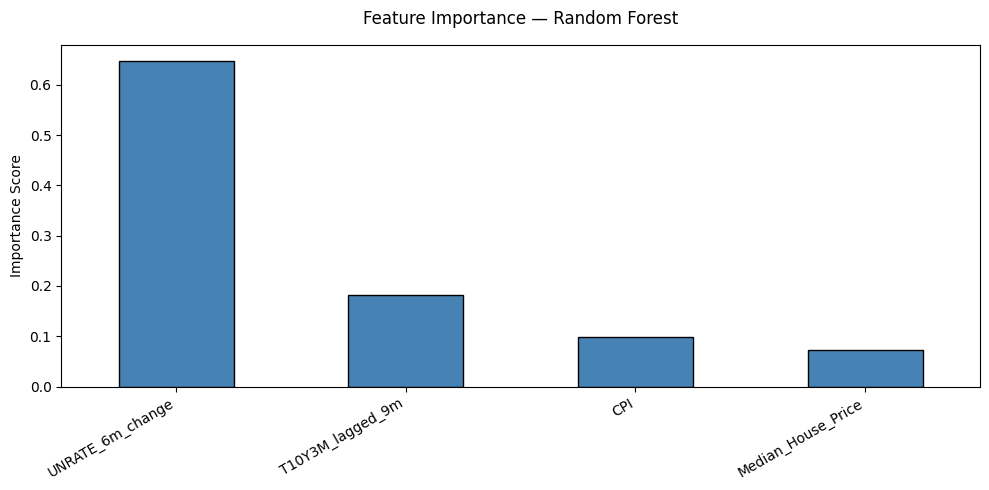

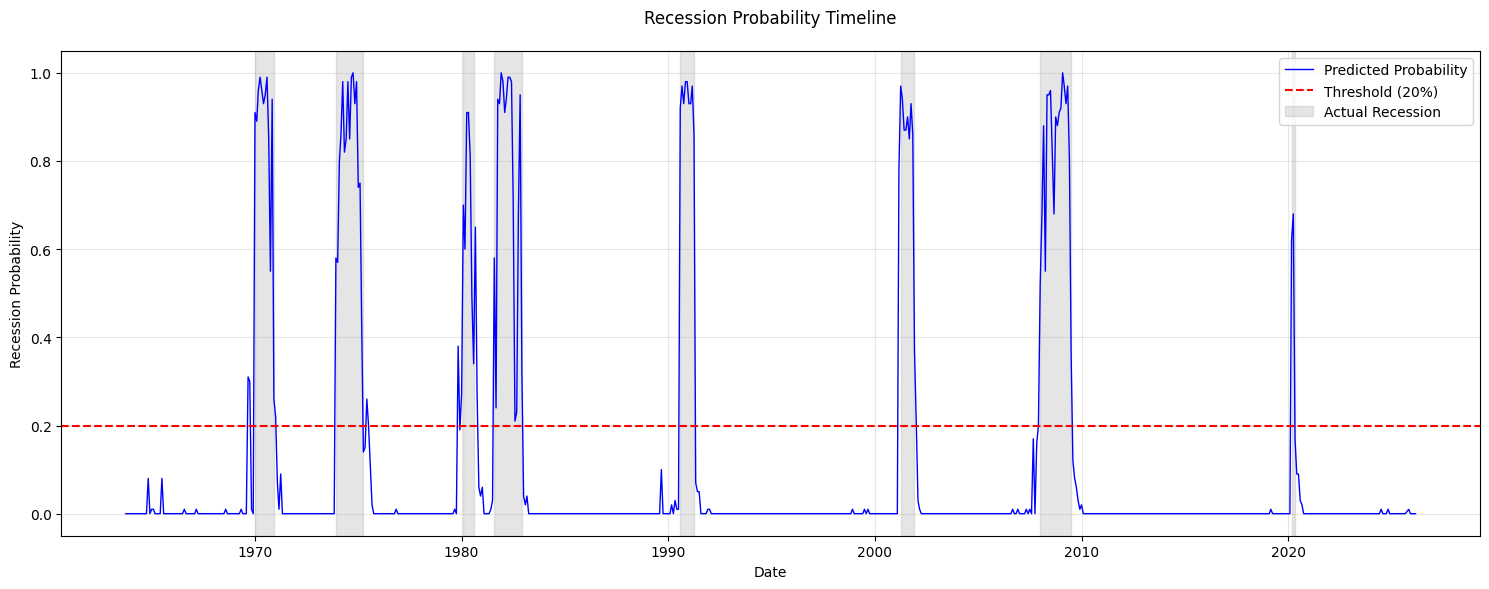

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# STEP 1 — Load and prepare data
# ─────────────────────────────────────────────
df = pd.read_csv("Final_merged_data.csv", parse_dates=["DATE"])
df = df.dropna()

print("Columns in dataset:", df.columns.tolist())
print(f"Shape: {df.shape}")

# ─────────────────────────────────────────────
# STEP 2 — Feature Engineering
# ─────────────────────────────────────────────
df['T10Y3M_lagged_9m']  = df['T10Y3M'].shift(9)      # Yield curve lagged 9 months
df['UNRATE_6m_change']  = df['UNRATE'].diff(6)        # Unemployment 6-month change

df = df.dropna()  # Drop rows that became NaN after engineering

# ─────────────────────────────────────────────
# STEP 3 — Define Features & Target
# ─────────────────────────────────────────────
feature_cols = [
    'USOIL',
    'UNRATE_6m_change',
    'S&P500',
    'T10Y3M_lagged_9m',
    'CPI',
    'Median_House_Price'
]

# Keep only columns that exist in the dataframe
feature_cols = [c for c in feature_cols if c in df.columns]
print(f"Features used: {feature_cols}")

X = df[feature_cols]
y = df['USREC']

print(f"\nClass distribution:\n{y.value_counts()}")

# ─────────────────────────────────────────────
# STEP 4 — Train / Test Split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─────────────────────────────────────────────
# STEP 5 — Random Forest Model
# ─────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy Scores (5-fold): {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

# Train on training set
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred      = rf_model.predict(X_test)
y_proba_test = rf_model.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, y_proba_test):.3f}")

# ─────────────────────────────────────────────
# STEP 6 — Feature Importance
# ─────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance — Random Forest", pad=15)
plt.ylabel("Importance Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# STEP 7 — Recession Probability Timeline
# ─────────────────────────────────────────────
custom_threshold = 0.2
df['Recession_Prob'] = rf_model.predict_proba(X)[:, 1]

plt.figure(figsize=(15, 6))
plt.plot(df['DATE'], df['Recession_Prob'], label='Predicted Probability', color='blue', linewidth=1)
plt.axhline(custom_threshold, color='red', linestyle='--', label=f'Threshold ({custom_threshold:.0%})')

# Shade actual recession periods
start = None
for i in range(1, len(df)):
    if df['USREC'].iloc[i] == 1 and df['USREC'].iloc[i-1] == 0:
        start = df['DATE'].iloc[i]
    elif df['USREC'].iloc[i] == 0 and df['USREC'].iloc[i-1] == 1 and start is not None:
        plt.axvspan(start, df['DATE'].iloc[i], color='gray', alpha=0.2, label='Actual Recession')
        start = None

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("Recession Probability Timeline", pad=20)
plt.xlabel("Date")
plt.ylabel("Recession Probability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Columns in dataset: ['DATE', 'T10Y3M', 'CPI', 'S&P500', 'Median_House_Price', 'UNRATE', 'USREC', 'USOIL']
Shape: (758, 8)

Features used: ['USOIL', 'UNRATE_6m_change', 'UNRATE_3m_change', 'S&P500', 'T10Y3M_lagged_9m', 'T10Y3M_lagged_12m', 'CPI', 'CPI_12m_change', 'Median_House_Price']

Class distribution:
USREC
0    661
1     85
Name: count, dtype: int64

Cross-Validation Accuracy Scores (TimeSeriesSplit): [0.80645161 0.99193548 0.93548387 0.84677419 0.99193548]
Mean Accuracy: 0.915 (±0.076)

Confusion Matrix:
[[128   5]
 [  3  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       133
           1       0.74      0.82      0.78        17

    accuracy                           0.95       150
   macro avg       0.86      0.89      0.87       150
weighted avg       0.95      0.95      0.95       150

AUC Score: 0.984


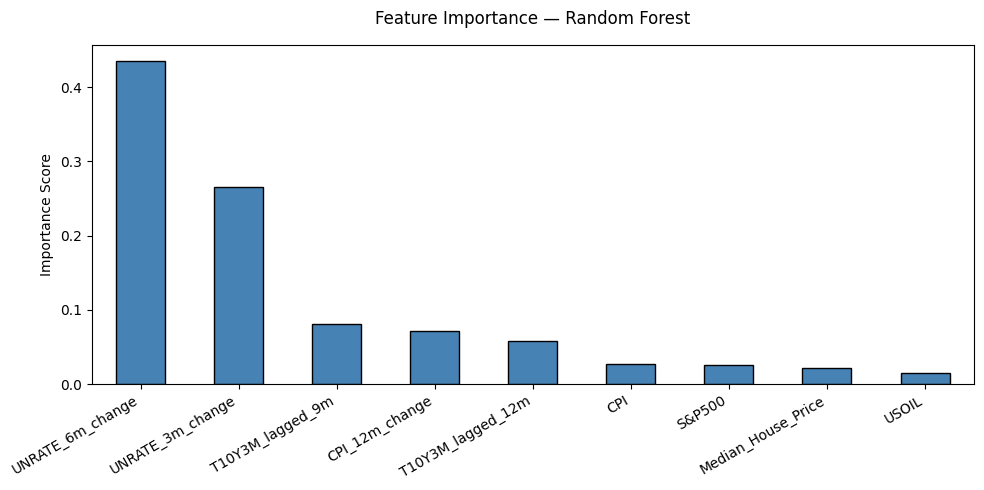

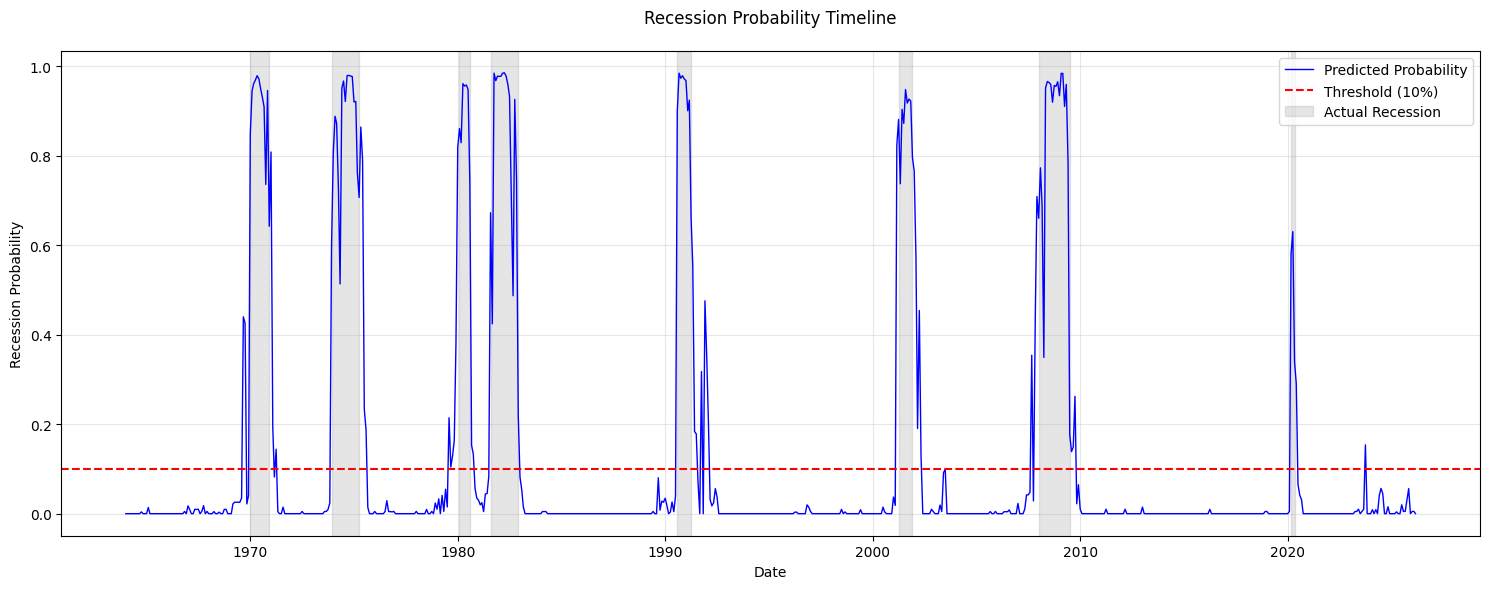

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# STEP 1 — Load and prepare data
# ─────────────────────────────────────────────
df = pd.read_csv("Final_merged_data.csv", parse_dates=["DATE"])
df = df.dropna()

# Fix column names so features are recognised
df = df.rename(columns={"WTISPLC": "USOIL", "SP500": "S&P500"})

print("Columns in dataset:", df.columns.tolist())
print(f"Shape: {df.shape}")

# ─────────────────────────────────────────────
# STEP 2 — Feature Engineering
# ─────────────────────────────────────────────
df['T10Y3M_lagged_9m']  = df['T10Y3M'].shift(9)       # Yield curve lagged 9 months
df['T10Y3M_lagged_12m'] = df['T10Y3M'].shift(12)      # Yield curve lagged 12 months
df['UNRATE_6m_change']  = df['UNRATE'].diff(6)         # Unemployment 6-month change
df['UNRATE_3m_change']  = df['UNRATE'].diff(3)         # Unemployment 3-month change
df['CPI_12m_change']    = df['CPI'].pct_change(12)     # Year-over-year inflation

df = df.dropna()  # Drop rows that became NaN after engineering

# ─────────────────────────────────────────────
# STEP 3 — Define Features & Target
# ─────────────────────────────────────────────
feature_cols = [
    'USOIL',
    'UNRATE_6m_change',
    'UNRATE_3m_change',
    'S&P500',
    'T10Y3M_lagged_9m',
    'T10Y3M_lagged_12m',
    'CPI',
    'CPI_12m_change',
    'Median_House_Price'
]

# Keep only columns that exist in the dataframe
feature_cols = [c for c in feature_cols if c in df.columns]
print(f"\nFeatures used: {feature_cols}")

X = df[feature_cols]
y = df['USREC']

print(f"\nClass distribution:\n{y.value_counts()}")

# ─────────────────────────────────────────────
# STEP 4 — Train / Test Split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─────────────────────────────────────────────
# STEP 5 — Random Forest Model (improved)
# ─────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,     # More trees for stability
    max_depth=6,          # Prevents overfitting
    class_weight='balanced',
    random_state=42
)

# TimeSeriesSplit cross-validation (respects time order, no future leakage)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf_model, X, y, cv=tscv, scoring='accuracy')
print(f"\nCross-Validation Accuracy Scores (TimeSeriesSplit): {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

# Train on training set
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred       = rf_model.predict(X_test)
y_proba_test = rf_model.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, y_proba_test):.3f}")

# ─────────────────────────────────────────────
# STEP 6 — Feature Importance
# ─────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance — Random Forest", pad=15)
plt.ylabel("Importance Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# STEP 7 — Recession Probability Timeline
# ─────────────────────────────────────────────
custom_threshold = 0.10   # Lowered from 0.20 to catch recessions earlier

df['Recession_Prob'] = rf_model.predict_proba(X)[:, 1]

plt.figure(figsize=(15, 6))
plt.plot(df['DATE'], df['Recession_Prob'], label='Predicted Probability', color='blue', linewidth=1)
plt.axhline(custom_threshold, color='red', linestyle='--', label=f'Threshold ({custom_threshold:.0%})')

# Shade actual recession periods
start = None
for i in range(1, len(df)):
    if df['USREC'].iloc[i] == 1 and df['USREC'].iloc[i-1] == 0:
        start = df['DATE'].iloc[i]
    elif df['USREC'].iloc[i] == 0 and df['USREC'].iloc[i-1] == 1 and start is not None:
        plt.axvspan(start, df['DATE'].iloc[i], color='gray', alpha=0.2, label='Actual Recession')
        start = None

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("Recession Probability Timeline", pad=20)
plt.xlabel("Date")
plt.ylabel("Recession Probability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()